In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
import statsmodels.api as sm

In [2]:
data = pd.read_csv(r"C:\Users\Sunny\Documents\Career rebuild\Day20\AirPassengers.csv", header = 0, index_col = 0)

In [3]:
data.head()

,#Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


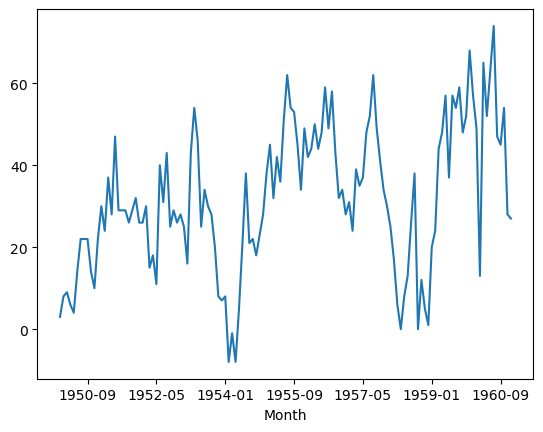

ADF Statistic: -3.375189
p-value: 0.011834
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


In [4]:
#Q3) Apply differencing to make it stationary, since p-value <= 0.05 we can reject the null hypotheses and state that data is stationary
data['Differenced'] = data['#Passengers'].diff(12)

data['Differenced'].plot()
plt.show()

X_diff = data['Differenced'].dropna().values
result_diff = adfuller(X_diff[1:])
print('ADF Statistic: %f' % result_diff[0])
print('p-value: %f' % result_diff[1])
print('Critical Values:')
for key, value in result_diff[4].items():
	print('\t%s: %.3f' % (key, value))

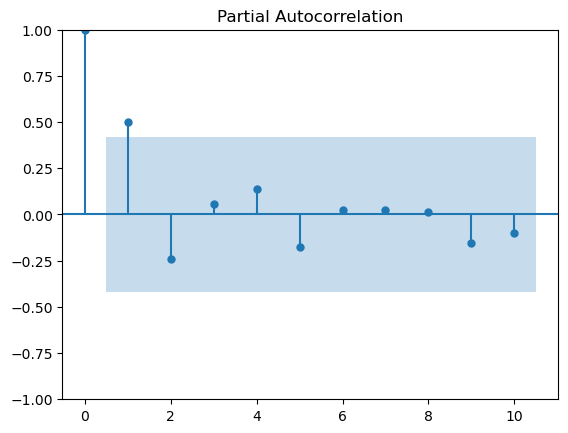

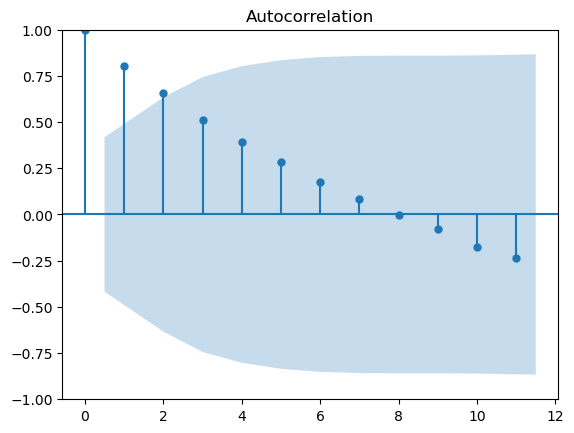

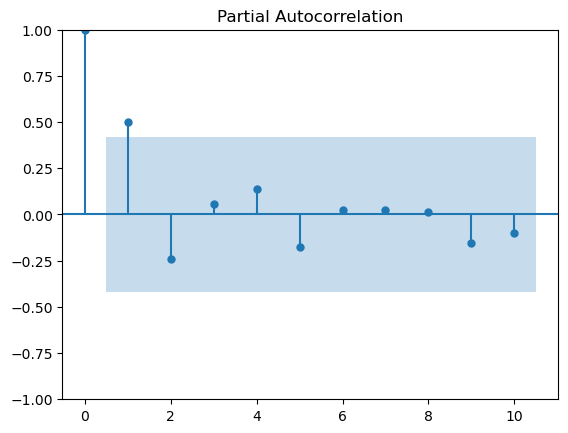

In [5]:
# plotting acf and pcf
lag_acf = acf(data['Differenced'].dropna())
lag_pacf = pacf(data['Differenced'].dropna())

plot_acf(lag_acf)
plot_pacf(lag_pacf, lags=10)

In [21]:
model = ARIMA(data['#Passengers'],order = (2,1,2))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Fri, 17 Apr 2026   AIC                           1353.347
Time:                        18:55:31   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9549      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.834      0.0

C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
#Q1) Forecast Air Passengers 12 months ahead using ARIMA 

size = int(len(data) - 12)
train, test = data['#Passengers'][0:size], data['#Passengers'][size:len(data)]

print('\t ARIMA MODEL : In- Sample Forecasting \n')

history = [x for x in train]
predictions = []

for t in range(len(test)):
    
    model = ARIMA(history, order=(2,1,2))
    model_fit = model.fit()
    
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(float(yhat))
    print(t)
    obs = np.array(test)[t]
    history.append(obs)
    
    print('predicted = %f, expected = %f' % (yhat, obs))

	 ARIMA MODEL : In- Sample Forecasting 

0
predicted = 411.312454, expected = 417.000000
1
predicted = 435.938008, expected = 391.000000
2
predicted = 418.796170, expected = 419.000000
3
predicted = 451.314950, expected = 461.000000
4
predicted = 488.382478, expected = 472.000000
5
predicted = 488.569097, expected = 535.000000
6
predicted = 532.219014, expected = 622.000000


C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


7
predicted = 601.215086, expected = 606.000000


C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


8
predicted = 563.035312, expected = 508.000000


C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


9
predicted = 452.854337, expected = 461.000000


C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


10
predicted = 415.007250, expected = 390.000000
11
predicted = 367.685740, expected = 432.000000


C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


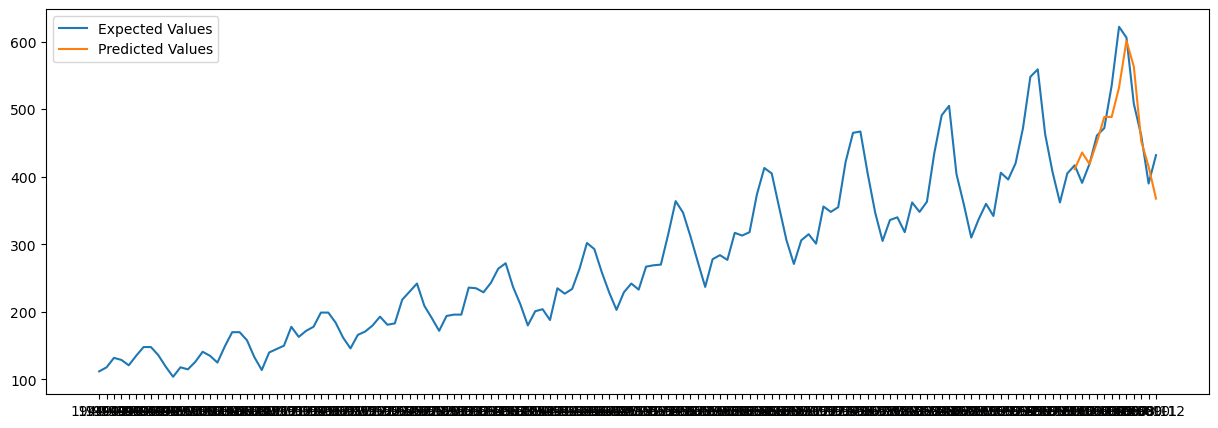

In [23]:
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.plot(data['#Passengers'],label = 'Expected Values')
plt.plot(predictions_series,label = 'Predicted Values');
plt.legend(loc="upper left")
plt.show()

In [24]:
#Q4) Calculate RMSE on held-out last 12 months
RMSE = np.sqrt(sum([(x-y)**2 for x,y in zip(predictions_series, test)]) / len(residuals))
RMSE

np.float64(41.34234483653594)

In [25]:
#Q2) Use auto_arima to find optimal parameters automatically
auto_arima_model = auto_arima(train, start_p = 0, d = 1, start_q = 0, max_p = 5, max_d = 5, 
                             max_q = 5, m = 12, start_P = 0, D = 1, start_Q = 0, max_P = 5, max_D = 5,
                             max_Q = 5, seasonal = True, error_action = 'warn', 
                             trace = True, suppress_warnings = True, stepwise = True,
                             random_state = 20, n_fits = 50)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=905.065, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=900.823, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=901.721, Time=0.19 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=899.902, Time=0.06 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=901.052, Time=0.17 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.91 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=901.337, Time=0.09 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=900.971, Time=0.10 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=900.685, Time=0.06 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=902.967, Time=0.20 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=901.457, Time=0.14 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 2.110 seconds


In [26]:
auto_arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -447.951
Date:                            Fri, 17 Apr 2026   AIC                            899.902
Time:                                    18:56:14   BIC                            905.460
Sample:                                01-01-1949   HQIC                           902.159
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2431      0.090     -2.697      0.007      -0.420      -0.066
sigma2       108.8757     13.306      8.183      0.000      82.797     134.954
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.57
Prob(Q):                              0.89   Prob(JB):                         0.75
Heteroskedasticity (H):               1.47   Skew:                            -0.03
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

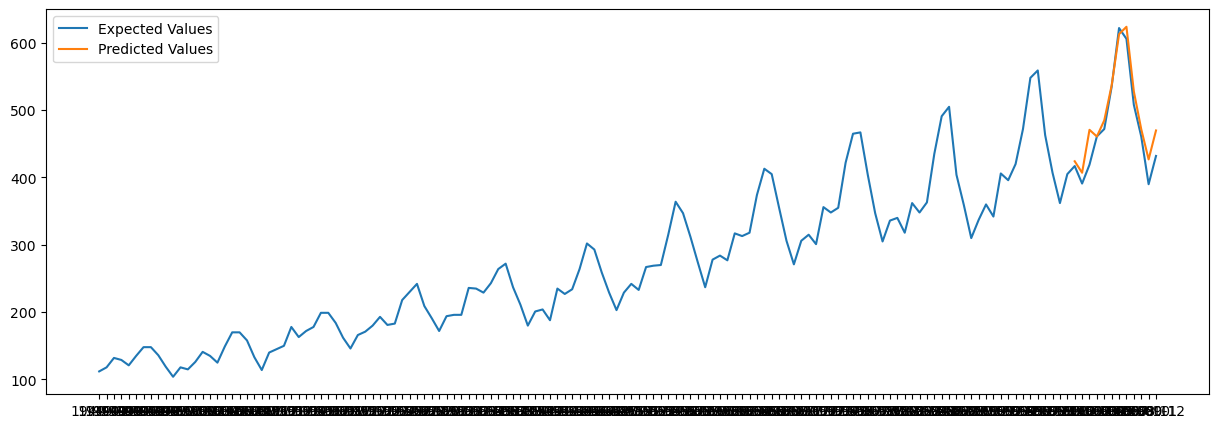

In [27]:
predictions = auto_arima_model.predict(n_periods = 12)
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.plot(data['#Passengers'],label = 'Expected Values')
plt.plot(predictions_series,label = 'Predicted Values');
plt.legend(loc="upper left")
plt.show()

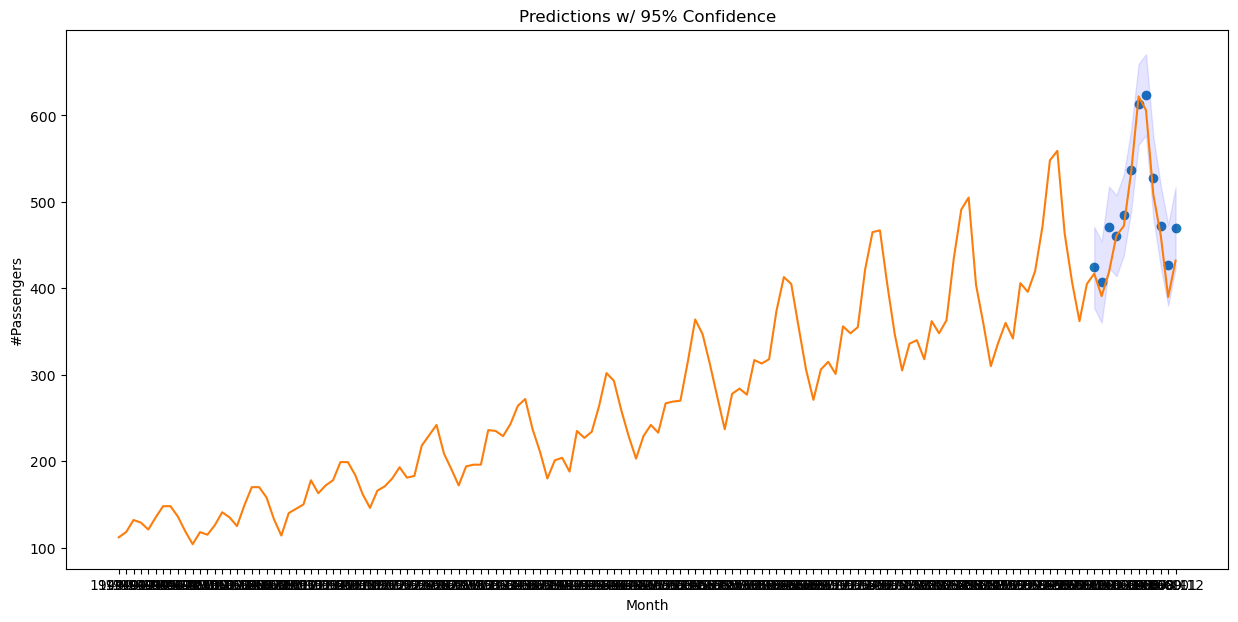

In [18]:
#Q3) Plot forecast with confidence intervals
residuals = [x - y for x, y in zip(predictions_series, test.values)]
RMSFE = np.sqrt(sum([x**2 for x in residuals]) / len(residuals))

band_size = 1.96*RMSFE

fig, ax = plt.subplots(figsize=(15,7))
ax.plot(data.index, data['#Passengers'], color='#fc7d0b', label='#Passengers')
ax.scatter(test.index, predictions_series)
ax.fill_between(test.index, (predictions_series - band_size), (predictions_series + band_size), color='b', alpha=.1)
ax.set_title("Predictions w/ 95% Confidence")
ax.set_xlabel('Month')
ax.set_ylabel('#Passengers')
plt.show()

In [28]:
sarima_result_diff = adfuller(data['Differenced'].dropna().values)
print('ADF Statistic: %f' % sarima_result_diff[0])
print('p-value: %f' % sarima_result_diff[1])
print('Critical Values:')
for key, value in sarima_result_diff[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.383021
p-value: 0.011551
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


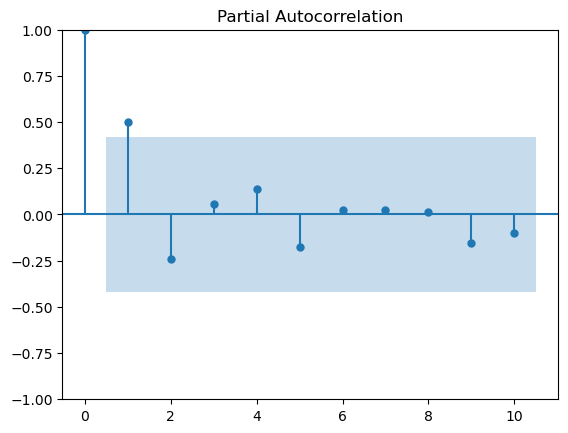

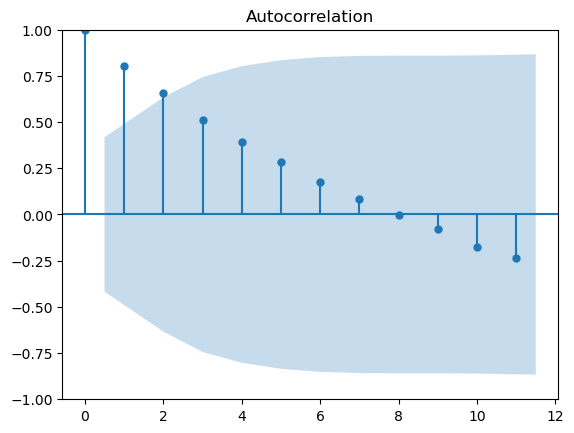

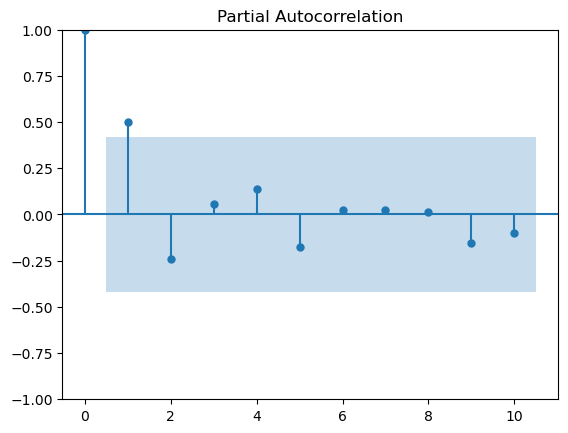

In [29]:
# plotting acf and pcf
lag_acf = acf(data['Differenced'].dropna())
lag_pacf = pacf(data['Differenced'].dropna())

plot_acf(lag_acf)
plot_pacf(lag_pacf, lags=10)

In [30]:
#Q5) Try SARIMA — does accounting for seasonality improve the forecast?
model = sm.tsa.statespace.SARIMAX(data['#Passengers'],order = (2,1,2),seasonal_order = (0,1,1,12))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Sunny\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                          #Passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -503.968
Date:                              Fri, 17 Apr 2026   AIC                           1019.935
Time:                                      18:58:09   BIC                           1037.186
Sample:                                  01-01-1949   HQIC                          1026.945
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3966      0.422      0.940      0.347      -0.430       1.223
ar.L2          0.35

In [31]:
size = int(len(data) - 12)
train, test = data['#Passengers'][0:size], data['#Passengers'][size:len(data)]

print('\t SARIMA MODEL : In - Sample Forecasting \n')

history = [x for x in train]
predictions = []

for t in range(len(test)):
    
    model = sm.tsa.statespace.SARIMAX(history,order = (2,1,2),seasonal_order = (0,1,1,12))
    model_fit = model.fit()
    
    output = model_fit.forecast()
    
    yhat = output[0]
    predictions.append(float(yhat))
    
    obs = test.iloc[t]
    history.append(obs)
    
    print('predicted = %f, expected = %f' % (yhat, obs))

	 SARIMA MODEL : In - Sample Forecasting 

predicted = 420.144016, expected = 417.000000
predicted = 397.755392, expected = 391.000000
predicted = 451.335535, expected = 419.000000
predicted = 415.675337, expected = 461.000000
predicted = 465.295965, expected = 472.000000
predicted = 529.835405, expected = 535.000000
predicted = 599.299656, expected = 622.000000
predicted = 626.292199, expected = 606.000000
predicted = 513.891979, expected = 508.000000
predicted = 450.136744, expected = 461.000000
predicted = 411.653930, expected = 390.000000
predicted = 438.411443, expected = 432.000000


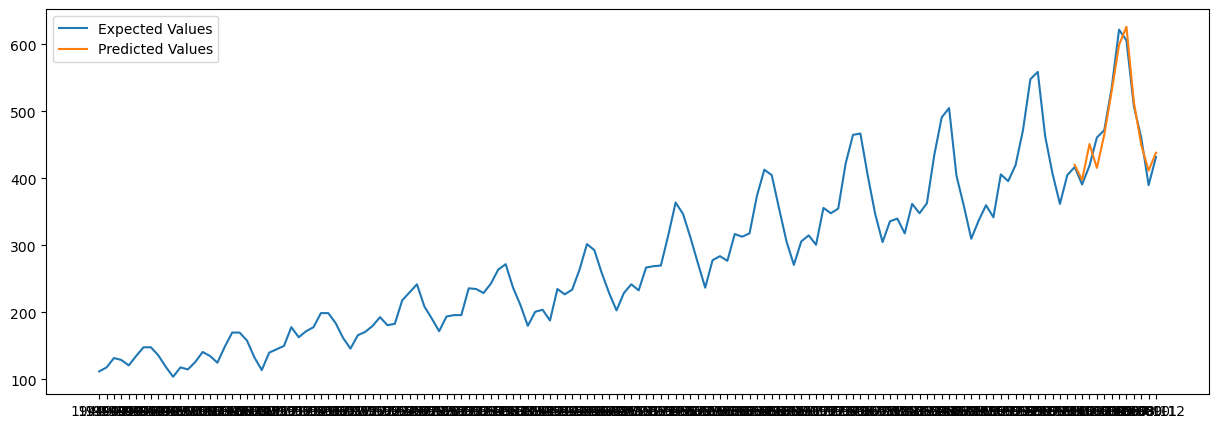

In [32]:
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.plot(data['#Passengers'],label = 'Expected Values')
plt.plot(predictions_series,label = 'Predicted Values');
plt.legend(loc="upper left")
plt.show()

In [33]:
#Q4) Calculate RMSE on held-out last 12 months
RMSE = np.sqrt(sum([(x-y)**2 for x,y in zip(predictions_series, test)]) / len(residuals))
RMSE

np.float64(20.035079937862534)